# EMIF notebook - Taylor rule with MA(1), market efficiency tests, and HAR-MA(1)

This notebook uses the Excel file `Data_HEC4.xlsx` and does three things, all in English:

1. **Dataset 1 - Taylor rule**  
   Estimate a Taylor rule with **MA(1) noise** by maximum likelihood, where the likelihood is computed **recursively**.  
   Standard errors are obtained with the **outer product of numerical scores (OPG)** built from the individual log-likelihood contributions.

2. **Dataset 2 - Market efficiency tests**  
   Compute weekly log returns, run **Ljung-Box** and **Box-Pierce** tests, and plot the **ACF** and **PACF**.

3. **Dataset 3 - HAR-MA(1)**  
   Estimate a **HAR(1,5,20)** model for daily realized variance with **MA(1) noise** by maximum likelihood, again with recursive likelihood and OPG standard errors.

The notebook also exports key tables and figures to an `TP4_outputs/` folder for LaTeX slides.


In [1]:
import os
os.makedirs("TP4_outputs", exist_ok=True)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use("default")


In [2]:
# Paths
BASE_DIR = os.getcwd()
DATA_FILE = os.path.join(BASE_DIR, "Data_HEC4.xlsx")
EXPORT_DIR = os.path.join(BASE_DIR, "TP4_outputs")
os.makedirs(EXPORT_DIR, exist_ok=True)

# The user explicitly asked to load the data with index_col=0
dataset1 = pd.read_excel(DATA_FILE, sheet_name="Dataset1", index_col=0)
dataset2 = pd.read_excel(DATA_FILE, sheet_name="Dataset2", index_col=0)
dataset3 = pd.read_excel(DATA_FILE, sheet_name="Dataset3", index_col=0)

for df in [dataset1, dataset2, dataset3]:
    df.index = pd.to_datetime(df.index)

dataset1.head()


,Fed Fund Rates,US Inflation,Output Gap
1971-03-31,5.5,4.712,-0.743500
1971-04-30,5.5,4.156,-0.792000
1971-05-31,5.5,4.404,-0.889000
1971-06-30,5.5,4.639,-0.901333
1971-07-31,5.5,4.359,-0.913667


## Helper functions

Two points are central here:

- the **MA(1) likelihood is recursive**,
- the **standard errors** come from the **OPG matrix**, built from **numerical derivatives** of the individual log-likelihood contributions.


In [3]:
def numerical_score_matrix(loglik_contrib_func, params, *args):
    """Numerical score matrix using central differences.

    Returns a T x K matrix. Row t is the score contribution of observation t.
    """
    params = np.asarray(params, dtype=float)
    k = len(params)
    h = 1e-5 * np.maximum(np.abs(params), 1.0)

    base = loglik_contrib_func(params, *args)
    T = len(base)
    scores = np.empty((T, k))

    for j in range(k):
        step = h[j]
        params_plus = params.copy()
        params_minus = params.copy()
        params_plus[j] += step
        params_minus[j] -= step

        ll_plus = loglik_contrib_func(params_plus, *args)
        ll_minus = loglik_contrib_func(params_minus, *args)

        scores[:, j] = (ll_plus - ll_minus) / (2.0 * step)

    return scores


def opg_standard_errors(loglik_contrib_func, params, *args):
    """OPG covariance estimator:
        Var(theta_hat) ~= (sum_t s_t s_t')^{-1}
    where s_t is the score contribution of observation t.
    """
    scores = numerical_score_matrix(loglik_contrib_func, params, *args)
    information_matrix = scores.T @ scores
    covariance = np.linalg.inv(information_matrix)
    std_errors = np.sqrt(np.diag(covariance))
    return std_errors, covariance, scores


def fmt_number(x):
    if pd.isna(x):
        return ""
    if abs(x) >= 1e-3:
        return f"{x:.4f}"
    return f"{x:.3e}"


# 1. Dataset 1 - Taylor rule with MA(1) noise

We estimate:

\[
i_t = \alpha + \beta_\pi \pi_t + \beta_y y^{gap}_t + u_t,
\]

with

\[
u_t = \varepsilon_t + \theta \varepsilon_{t-1}, \qquad \varepsilon_t \sim \mathcal{N}(0,\sigma^2).
\]

Because the error term is MA(1), the innovation must be recovered **recursively**:

\[
\varepsilon_t = i_t - \alpha - \beta_\pi \pi_t - \beta_y y^{gap}_t - \theta \varepsilon_{t-1}.
\]

This is exactly the recursion requested in the course note.


In [4]:
def taylor_ma1_loglik_contrib(params, y, X):
    """Individual log-likelihood contributions for the Taylor rule with MA(1) noise.

    params = [alpha, beta_pi, beta_gap, theta, log_sigma]
    The likelihood is computed recursively:
        eps_t = y_t - X_t beta - theta * eps_{t-1}
    """
    beta = params[:-2]
    theta = params[-2]
    sigma = np.exp(params[-1])

    ll = np.empty(len(y))
    eps_prev = 0.0

    for t in range(len(y)):
        mean_t = X[t] @ beta + theta * eps_prev
        eps_t = y[t] - mean_t
        ll[t] = -0.5 * (np.log(2.0 * np.pi) + 2.0 * np.log(sigma) + (eps_t / sigma) ** 2)
        eps_prev = eps_t

    return ll


def taylor_ma1_filter(params, y, X):
    """Return recursive fitted values and innovations."""
    beta = params[:-2]
    theta = params[-2]

    fitted = np.empty(len(y))
    innovations = np.empty(len(y))
    eps_prev = 0.0

    for t in range(len(y)):
        fitted[t] = X[t] @ beta + theta * eps_prev
        innovations[t] = y[t] - fitted[t]
        eps_prev = innovations[t]

    return fitted, innovations


y1 = dataset1["Fed Fund Rates"].to_numpy(dtype=float)
X1 = np.column_stack([
    np.ones(len(dataset1)),
    dataset1["US Inflation"].to_numpy(dtype=float),
    dataset1["Output Gap"].to_numpy(dtype=float),
])

# OLS benchmark
ols_taylor = sm.OLS(y1, X1).fit()

# MA(1) MLE
start_params_1 = np.array([
    ols_taylor.params[0],
    ols_taylor.params[1],
    ols_taylor.params[2],
    0.20,
    np.log(np.std(ols_taylor.resid))
])

result_taylor_ma1 = minimize(
    lambda p: -taylor_ma1_loglik_contrib(p, y1, X1).sum(),
    start_params_1,
    method="L-BFGS-B",
    bounds=[(None, None), (None, None), (None, None), (-0.99, 0.99), (np.log(1e-8), None)],
)

taylor_params = result_taylor_ma1.x
taylor_fitted, taylor_innov = taylor_ma1_filter(taylor_params, y1, X1)
taylor_se, taylor_cov, taylor_scores = opg_standard_errors(taylor_ma1_loglik_contrib, taylor_params, y1, X1)

print("Optimization success:", result_taylor_ma1.success)
print("Log-likelihood:", taylor_ma1_loglik_contrib(taylor_params, y1, X1).sum())
pd.Series(
    [taylor_params[0], taylor_params[1], taylor_params[2], taylor_params[3], np.exp(taylor_params[4])],
    index=["Intercept", "Inflation coefficient", "Output gap coefficient", "MA(1) coefficient", "Innovation sd"],
    name="MA(1) MLE estimates",
)


Optimization success: True
Log-likelihood: -1250.641964598105


Intercept                 1.577859
Inflation coefficient     0.870644
Output gap coefficient    0.209632
MA(1) coefficient         0.809937
Innovation sd             1.609574
Name: MA(1) MLE estimates, dtype: float64

## Why the OPG standard errors are valid here

For the exact likelihood, the information matrix equality gives:

$
-\mathbb{E}\left[\frac{\partial^2 \ell_t(\theta)}{\partial \theta \partial \theta'}\right]
=
\mathbb{E}\left[
\frac{\partial \ell_t(\theta)}{\partial \theta}
\frac{\partial \ell_t(\theta)}{\partial \theta'}
\right].
$

So, instead of approximating the Hessian directly, we build the covariance matrix from the **outer product of the numerical score contributions**:

$
\widehat{\mathcal I}(\theta)
=
\sum_{t=1}^T s_t(\theta)s_t(\theta)'.
$

This is exactly what the helper function above computes.


In [5]:
taylor_table = pd.DataFrame({
    "Parameter": ["Intercept", "Inflation coefficient", "Output gap coefficient", "MA(1) coefficient", "Innovation sd"],
    "OLS estimate": [ols_taylor.params[0], ols_taylor.params[1], ols_taylor.params[2], np.nan, np.std(ols_taylor.resid, ddof=3)],
    "OLS std. err.": [ols_taylor.bse[0], ols_taylor.bse[1], ols_taylor.bse[2], np.nan, np.nan],
    "MA(1) MLE estimate": [taylor_params[0], taylor_params[1], taylor_params[2], taylor_params[3], np.exp(taylor_params[4])],
    "MA(1) MLE std. err.": [taylor_se[0], taylor_se[1], taylor_se[2], taylor_se[3], np.exp(taylor_params[4]) * taylor_se[4]],
})
taylor_table


,Parameter,OLS estimate,OLS std. err.,MA(1) MLE estimate,MA(1) MLE std. err.
0,Intercept,1.503098,0.180232,1.577859,0.232048
1,Inflation coefficient,0.891424,0.035821,0.870644,0.030704
2,Output gap coefficient,0.220122,0.051187,0.209632,0.056862
3,MA(1) coefficient,NaN,NaN,0.809937,0.014956
4,Innovation sd,2.671527,NaN,1.609574,0.037462


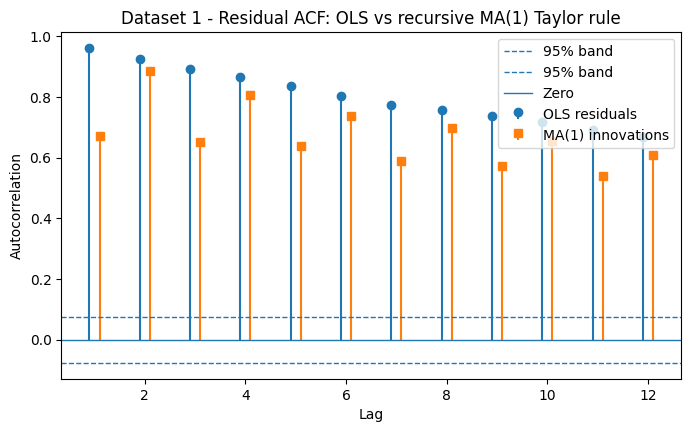

In [6]:
# Compare the residual ACFs
acf_ols = acf(ols_taylor.resid, nlags=12, fft=False)
acf_ma1 = acf(taylor_innov, nlags=12, fft=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
lags = np.arange(1, 13)
ax.stem(lags - 0.1, acf_ols[1:13], linefmt="C0-", markerfmt="C0o", basefmt=" ")
ax.stem(lags + 0.1, acf_ma1[1:13], linefmt="C1-", markerfmt="C1s", basefmt=" ")
band = 1.96 / np.sqrt(len(y1))
ax.axhline(band, linestyle="--", linewidth=1)
ax.axhline(-band, linestyle="--", linewidth=1)
ax.axhline(0.0, linewidth=1)
ax.set_title("Dataset 1 - Residual ACF: OLS vs recursive MA(1) Taylor rule")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.legend(["95% band", "95% band", "Zero", "OLS residuals", "MA(1) innovations"], loc="upper right")
plt.show()


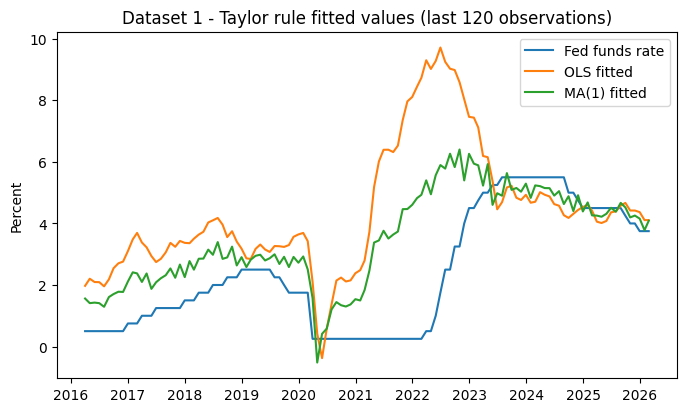

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dataset1.index[-120:], y1[-120:], label="Fed funds rate")
ax.plot(dataset1.index[-120:], ols_taylor.fittedvalues[-120:], label="OLS fitted")
ax.plot(dataset1.index[-120:], taylor_fitted[-120:], label="MA(1) fitted")
ax.set_title("Dataset 1 - Taylor rule fitted values (last 120 observations)")
ax.set_ylabel("Percent")
ax.legend()
plt.show()


### Comment

The MA(1) specification changes the coefficient estimates and short-run dynamics relative to plain OLS.  
But the residual ACF remains informative: if the innovation ACF still shows persistence, then a **single MA lag is not enough** to fully absorb the serial dependence in the policy rule residuals.


# 2. Dataset 2 - Autocorrelation tests and weak-form efficiency

We first transform the price index into weekly **log returns**:

$
r_t = \log(P_t) - \log(P_{t-1}).
$

Then we look at:
- the **Ljung-Box** test,
- the **Box-Pierce** test,
- the **ACF** and **PACF** of returns.


In [8]:
prices2 = dataset2["S&P500"].astype(float)
returns2 = np.log(prices2).diff().dropna()

tests2 = acorr_ljungbox(returns2, lags=[5, 10, 20], boxpierce=True, return_df=True)
tests2 = tests2.reset_index().rename(columns={
    "index": "Lag",
    "lb_stat": "Ljung-Box stat",
    "lb_pvalue": "Ljung-Box p-value",
    "bp_stat": "Box-Pierce stat",
    "bp_pvalue": "Box-Pierce p-value",
})
tests2


,Lag,Ljung-Box stat,Ljung-Box p-value,Box-Pierce stat,Box-Pierce p-value
0,5,11.105828,0.049322,11.008936,0.051203
1,10,12.777172,0.236399,12.646799,0.244095
2,20,18.655926,0.544282,18.306194,0.567246


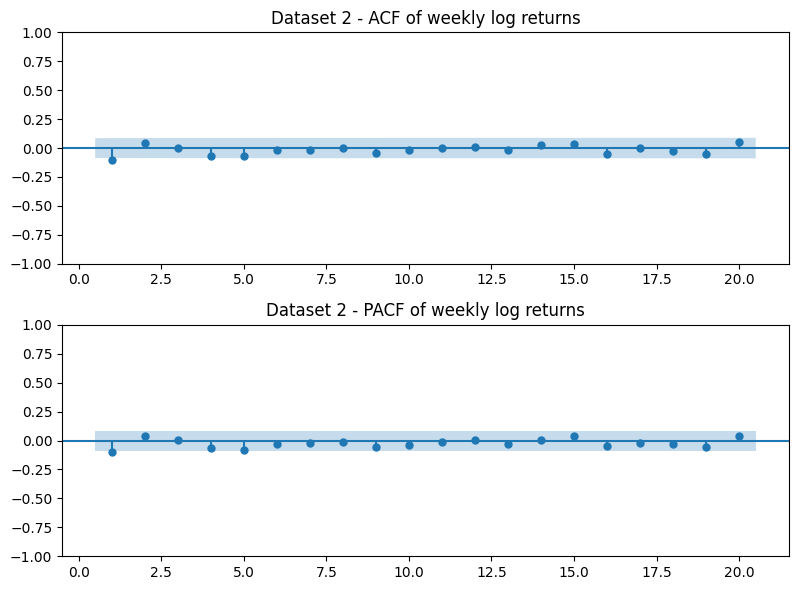

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
plot_acf(returns2, lags=20, ax=axes[0], zero=False)
axes[0].set_title("Dataset 2 - ACF of weekly log returns")
plot_pacf(returns2, lags=20, ax=axes[1], zero=False, method="ywm")
axes[1].set_title("Dataset 2 - PACF of weekly log returns")
plt.tight_layout()
plt.show()


### Conclusion on market efficiency

The evidence is mostly consistent with **weak-form efficiency**:
- at most horizons, the joint autocorrelation tests do **not** reject the null of no serial correlation,
- the ACF and PACF do not show a strong, stable pattern.

There can still be an occasional marginal rejection at a short horizon, but that is not enough to conclude that weekly returns are predictably autocorrelated in a robust way.


# 3. Dataset 3 - HAR model with MA(1) noise

We estimate:


$
RV_t = \beta_0 + \beta_1 RV_{t-1} + \beta_5 \overline{RV}_{t-1:t-5} + \beta_{20} \overline{RV}_{t-1:t-20} + u_t,
$

with

$u_t = \varepsilon_t + \theta \varepsilon_{t-1}, \qquad \varepsilon_t \sim \mathcal{N}(0,\sigma^2).
$

Again, the likelihood is computed recursively.


In [10]:
def build_har_dataset(rv_series):
    df = pd.DataFrame({"rv": rv_series.astype(float)})
    df["rv_1"] = df["rv"].shift(1)
    df["rv_5"] = df["rv"].shift(1).rolling(5).mean()
    df["rv_20"] = df["rv"].shift(1).rolling(20).mean()
    return df.dropna()


def har_ma1_loglik_contrib(params, y, X):
    """Recursive log-likelihood contributions for HAR-MA(1).

    params = [beta0, beta1, beta5, beta20, theta, log_sigma]
    """
    beta = params[:-2]
    theta = params[-2]
    sigma = np.exp(params[-1])

    ll = np.empty(len(y))
    eps_prev = 0.0

    for t in range(len(y)):
        mean_t = X[t] @ beta + theta * eps_prev
        eps_t = y[t] - mean_t
        ll[t] = -0.5 * (np.log(2.0 * np.pi) + 2.0 * np.log(sigma) + (eps_t / sigma) ** 2)
        eps_prev = eps_t

    return ll


def har_ma1_filter(params, y, X):
    beta = params[:-2]
    theta = params[-2]

    fitted = np.empty(len(y))
    innovations = np.empty(len(y))
    eps_prev = 0.0

    for t in range(len(y)):
        fitted[t] = X[t] @ beta + theta * eps_prev
        innovations[t] = y[t] - fitted[t]
        eps_prev = innovations[t]

    return fitted, innovations


har_df = build_har_dataset(dataset3["S&P500 Realized Variance"])
y3 = har_df["rv"].to_numpy(dtype=float)
X3 = np.column_stack([
    np.ones(len(har_df)),
    har_df["rv_1"].to_numpy(dtype=float),
    har_df["rv_5"].to_numpy(dtype=float),
    har_df["rv_20"].to_numpy(dtype=float),
])

ols_har = sm.OLS(y3, X3).fit()

# A small multi-start approach helps because theta can be flat around zero.
candidate_results = []
for theta0 in [-0.8, -0.5, -0.2, 0.0, 0.2, 0.5, 0.8]:
    start_params_3 = np.array([
        ols_har.params[0],
        ols_har.params[1],
        ols_har.params[2],
        ols_har.params[3],
        theta0,
        np.log(np.std(ols_har.resid))
    ])

    res = minimize(
        lambda p: -har_ma1_loglik_contrib(p, y3, X3).sum(),
        start_params_3,
        method="L-BFGS-B",
        bounds=[(None, None), (None, None), (None, None), (None, None), (-0.99, 0.99), (np.log(1e-12), None)],
    )
    candidate_results.append(res)

result_har_ma1 = min(candidate_results, key=lambda r: r.fun)
har_params = result_har_ma1.x
har_fitted, har_innov = har_ma1_filter(har_params, y3, X3)
har_se, har_cov, har_scores = opg_standard_errors(har_ma1_loglik_contrib, har_params, y3, X3)

print("Optimization success:", result_har_ma1.success)
print("Log-likelihood:", har_ma1_loglik_contrib(har_params, y3, X3).sum())
pd.Series(
    [har_params[0], har_params[1], har_params[2], har_params[3], har_params[4], np.exp(har_params[5])],
    index=["Intercept", "Lag 1 RV", "Lag 5 average RV", "Lag 20 average RV", "MA(1) coefficient", "Innovation sd"],
    name="HAR-MA(1) estimates",
)


Optimization success: True
Log-likelihood: 23655.309243910982


Intercept            9.473044e-06
Lag 1 RV             2.787411e-01
Lag 5 average RV     4.610395e-01
Lag 20 average RV    1.734807e-01
MA(1) coefficient   -3.222955e-15
Innovation sd        1.556984e-04
Name: HAR-MA(1) estimates, dtype: float64

In [11]:
har_table = pd.DataFrame({
    "Parameter": ["Intercept", "Lag 1 RV", "Lag 5 average RV", "Lag 20 average RV", "MA(1) coefficient", "Innovation sd"],
    "Estimate": [har_params[0], har_params[1], har_params[2], har_params[3], har_params[4], np.exp(har_params[5])],
    "Std. err.": [har_se[0], har_se[1], har_se[2], har_se[3], har_se[4], np.exp(har_params[5]) * har_se[5]],
})
har_table["t-stat"] = har_table["Estimate"] / har_table["Std. err."]
har_table["p-value"] = 2.0 * (1.0 - norm.cdf(np.abs(har_table["t-stat"])))
har_table


,Parameter,Estimate,Std. err.,t-stat,p-value
0,Intercept,9.473044e-06,5.744895e-06,1.648950e+00,0.099158
1,Lag 1 RV,2.787411e-01,2.716808e-02,1.025988e+01,0.000000
2,Lag 5 average RV,4.610395e-01,1.979413e-02,2.329173e+01,0.000000
3,Lag 20 average RV,1.734807e-01,1.024077e-02,1.694020e+01,0.000000
4,MA(1) coefficient,-3.222955e-15,2.414441e-02,-1.334866e-13,1.000000
5,Innovation sd,1.556984e-04,2.587316e-07,6.017757e+02,0.000000


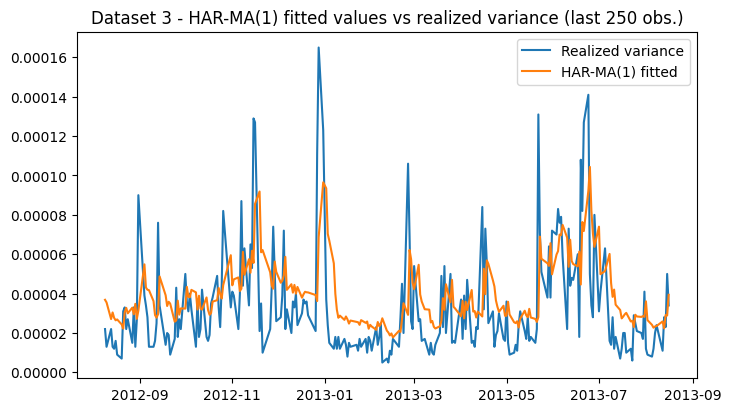

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(har_df.index[-250:], y3[-250:], label="Realized variance")
ax.plot(har_df.index[-250:], har_fitted[-250:], label="HAR-MA(1) fitted")
ax.set_title("Dataset 3 - HAR-MA(1) fitted values vs realized variance (last 250 obs.)")
ax.legend()
plt.show()


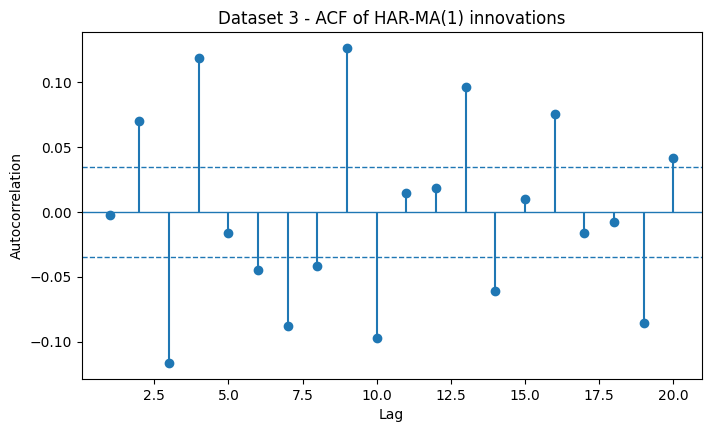

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
acf_har = acf(har_innov, nlags=20, fft=False)
lags = np.arange(1, 21)
ax.stem(lags, acf_har[1:21], basefmt=" ")
band = 1.96 / np.sqrt(len(y3))
ax.axhline(band, linestyle="--", linewidth=1)
ax.axhline(-band, linestyle="--", linewidth=1)
ax.axhline(0.0, linewidth=1)
ax.set_title("Dataset 3 - ACF of HAR-MA(1) innovations")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
plt.show()


### Conclusion

The HAR part is clearly important:
- the **daily**, **weekly**, and **monthly** realized variance components are economically meaningful,
- the medium-horizon terms are strongly significant,
- the MA(1) coefficient can be small, which means the persistence is mostly captured by the HAR structure itself rather than by the short-run moving-average correction.

So the data mainly support a **persistent multi-horizon volatility process**, which is exactly what the HAR model is designed to capture.


# Export tables and figures for LaTeX slides


In [14]:
# Save Dataset 1 table
taylor_table_export = taylor_table.copy()
for col in taylor_table_export.columns[1:]:
    taylor_table_export[col] = taylor_table_export[col].map(fmt_number)
taylor_table_export.to_csv(os.path.join(EXPORT_DIR, "dataset1_taylor_comparison.csv"), index=False)
with open(os.path.join(EXPORT_DIR, "dataset1_taylor_comparison.tex"), "w") as f:
    f.write(taylor_table_export.to_latex(index=False, escape=False))

# Save Dataset 2 table
tests2_export = tests2.copy()
for col in tests2_export.columns[1:]:
    tests2_export[col] = tests2_export[col].map(lambda x: f"{x:.4f}")
tests2_export.to_csv(os.path.join(EXPORT_DIR, "dataset2_autocorrelation_tests.csv"), index=False)
with open(os.path.join(EXPORT_DIR, "dataset2_autocorrelation_tests.tex"), "w") as f:
    f.write(tests2_export.to_latex(index=False, escape=False))

# Save Dataset 3 table
har_table_export = har_table.copy()
for col in har_table_export.columns[1:]:
    har_table_export[col] = har_table_export[col].map(fmt_number)
har_table_export.to_csv(os.path.join(EXPORT_DIR, "dataset3_har_ma1_results.csv"), index=False)
with open(os.path.join(EXPORT_DIR, "dataset3_har_ma1_results.tex"), "w") as f:
    f.write(har_table_export.to_latex(index=False, escape=False))


In [15]:
# Save figures again to the export folder

# Dataset 1 - ACF comparison
fig, ax = plt.subplots(figsize=(8, 4.5))
lags = np.arange(1, 13)
ax.stem(lags - 0.1, acf_ols[1:13], linefmt="C0-", markerfmt="C0o", basefmt=" ")
ax.stem(lags + 0.1, acf_ma1[1:13], linefmt="C1-", markerfmt="C1s", basefmt=" ")
band = 1.96 / np.sqrt(len(y1))
ax.axhline(band, linestyle="--", linewidth=1)
ax.axhline(-band, linestyle="--", linewidth=1)
ax.axhline(0.0, linewidth=1)
ax.set_title("Dataset 1 - Residual ACF: OLS vs recursive MA(1) Taylor rule")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.legend(["95% band", "95% band", "Zero", "OLS residuals", "MA(1) innovations"], loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(EXPORT_DIR, "dataset1_taylor_acf_comparison.pdf"))
fig.savefig(os.path.join(EXPORT_DIR, "dataset1_taylor_acf_comparison.png"), dpi=200)
plt.close(fig)

# Dataset 1 - fitted values
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dataset1.index[-120:], y1[-120:], label="Fed funds rate")
ax.plot(dataset1.index[-120:], ols_taylor.fittedvalues[-120:], label="OLS fitted")
ax.plot(dataset1.index[-120:], taylor_fitted[-120:], label="MA(1) fitted")
ax.set_title("Dataset 1 - Taylor rule fitted values (last 120 observations)")
ax.set_ylabel("Percent")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(EXPORT_DIR, "dataset1_taylor_fitted_values.pdf"))
fig.savefig(os.path.join(EXPORT_DIR, "dataset1_taylor_fitted_values.png"), dpi=200)
plt.close(fig)

# Dataset 2 - ACF/PACF
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
plot_acf(returns2, lags=20, ax=axes[0], zero=False)
axes[0].set_title("Dataset 2 - ACF of weekly log returns")
plot_pacf(returns2, lags=20, ax=axes[1], zero=False, method="ywm")
axes[1].set_title("Dataset 2 - PACF of weekly log returns")
fig.tight_layout()
fig.savefig(os.path.join(EXPORT_DIR, "dataset2_returns_acf_pacf.pdf"))
fig.savefig(os.path.join(EXPORT_DIR, "dataset2_returns_acf_pacf.png"), dpi=200)
plt.close(fig)

# Dataset 3 - fitted vs actual
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(har_df.index[-250:], y3[-250:], label="Realized variance")
ax.plot(har_df.index[-250:], har_fitted[-250:], label="HAR-MA(1) fitted")
ax.set_title("Dataset 3 - HAR-MA(1) fitted values vs realized variance (last 250 obs.)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(EXPORT_DIR, "dataset3_har_ma1_fitted_vs_actual.pdf"))
fig.savefig(os.path.join(EXPORT_DIR, "dataset3_har_ma1_fitted_vs_actual.png"), dpi=200)
plt.close(fig)

# Dataset 3 - innovation ACF
fig, ax = plt.subplots(figsize=(8, 4.5))
acf_har = acf(har_innov, nlags=20, fft=False)
lags = np.arange(1, 21)
ax.stem(lags, acf_har[1:21], basefmt=" ")
band = 1.96 / np.sqrt(len(y3))
ax.axhline(band, linestyle="--", linewidth=1)
ax.axhline(-band, linestyle="--", linewidth=1)
ax.axhline(0.0, linewidth=1)
ax.set_title("Dataset 3 - ACF of HAR-MA(1) innovations")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
fig.tight_layout()
fig.savefig(os.path.join(EXPORT_DIR, "dataset3_har_ma1_innovation_acf.pdf"))
fig.savefig(os.path.join(EXPORT_DIR, "dataset3_har_ma1_innovation_acf.png"), dpi=200)
plt.close(fig)

sorted(os.listdir(EXPORT_DIR))


['dataset1_taylor_acf_comparison.pdf',
 'dataset1_taylor_acf_comparison.png',
 'dataset1_taylor_comparison.csv',
 'dataset1_taylor_comparison.tex',
 'dataset1_taylor_fitted_values.pdf',
 'dataset1_taylor_fitted_values.png',
 'dataset2_autocorrelation_tests.csv',
 'dataset2_autocorrelation_tests.tex',
 'dataset2_returns_acf_pacf.pdf',
 'dataset2_returns_acf_pacf.png',
 'dataset3_har_ma1_fitted_vs_actual.pdf',
 'dataset3_har_ma1_fitted_vs_actual.png',
 'dataset3_har_ma1_innovation_acf.pdf',
 'dataset3_har_ma1_innovation_acf.png',
 'dataset3_har_ma1_results.csv',
 'dataset3_har_ma1_results.tex']

End of notebook.